# Data EDA, CLIP, Manual Feature extraction

In [ ]:
# lib

# Extract Features for model training

In [ ]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-g1cuwln6
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-g1cuwln6
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=4d8836c03760c5649e20ede1e69372352a83b600127bf10dd23d588fb8c0bc69
  Stored in directory: /tmp/pip-ephem-wheel-cache-3ht4_2zg/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
#
# colab access to drive
from google.colab import drive
drive.mount("/content/drive")


# current folder
import os
print(os.getcwd())

Mounted at /content/drive
/content


In [ ]:
BASE = "/content/drive/MyDrive/capstone"

In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [ ]:
CSV_PATH   = f"{BASE}/Project2data/raw/video_metadata.csv"  # metadata CSV goes into your raw folder

In [ ]:
df = pd.read_csv(CSV_PATH)

In [ ]:
print(f"Videos in CSV:      {len(df)}")
print(f"Thumbnails on disk: {len(list(Path(f'{BASE}/Project2data/thumbnails').glob('*.jpg')))}")

Videos in CSV:      4650
Thumbnails on disk: 3798


In [ ]:


df = pd.read_csv(CSV_PATH)
print(f"Videos loaded:      {len(df)}")
print(f"Thumbnails on disk: {len(list(Path(f'{BASE}/Project2data/thumbnails').glob('*.jpg')))}")
print(f"Long-form:          {(df['is_short']==False).sum()}")
print(f"Shorts:             {(df['is_short']==True).sum()}")
print("All imports successful ✓")


Videos loaded:      4650
Thumbnails on disk: 3798
Long-form:          2631
Shorts:             2019
All imports successful ✓


category
Music             1850
People & Blogs    1500
Gaming            1300
Name: count, dtype: int64


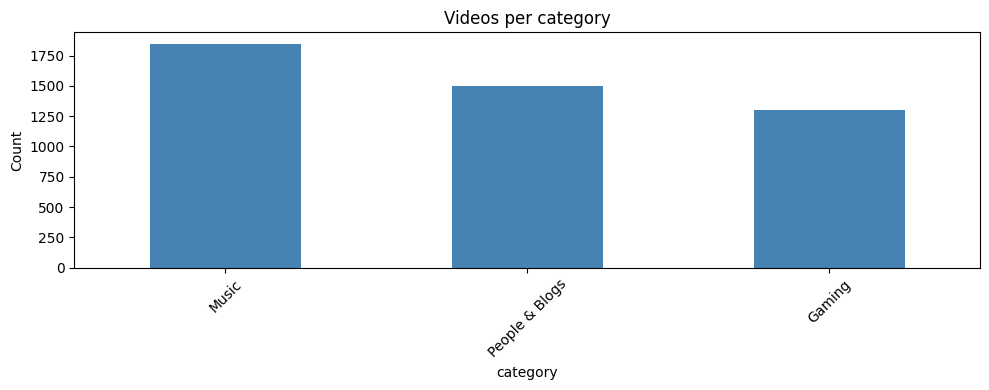

In [ ]:
print(df["category"].value_counts())

df["category"].value_counts().plot(kind="bar", figsize=(10,4), color="steelblue")
plt.title("Videos per category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Clip Embedding

CLIP is a neural network trained by OpenAI that learned to understand images and text together.

In [ ]:
import torch
import clip
import numpy as np
from PIL import Image
from pathlib import Path

In [ ]:
# selecting device for CLIP
device = "cuda" if torch.cuda.is_available() else "cpu"   # use GPU if available in Colab
print(f"Using device: {device}")

model, preprocess = clip.load("ViT-B/32", device=device)  # load CLIP model and image preprocessor
model.eval()

Using device: cuda


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 302MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [ ]:
# thumbnail file path
thumbnail_dir   = Path(f"{BASE}/Project2data/thumbnails")
thumbnail_paths = list(thumbnail_dir.glob("*.jpg"))
print(f"Found {len(thumbnail_paths)} thumbnails on disk")

# empty lists to collect results
embeddings = []   # will hold one 512-dim vector per image
video_ids  = []   # will hold the video_id matching each embedding


Found 3798 thumbnails on disk


In [ ]:
# looping through each thubnial image and ecoding it

for i, path in enumerate(thumbnail_paths):

    try:
        video_id = path.stem.split("_")[0]                 # extract video_id

        img = Image.open(path).convert("RGB")              # open image and ensure it is RGB (no alpha channel)
        img_tensor = preprocess(img).unsqueeze(0).to(device)  # preprocess and add batch dimension

        with torch.no_grad():
            features = model.encode_image(img_tensor)     # pass image through CLIP → get 512-dim vector which epresent everything it understood about that image — colors, faces, mood, composition, text presence
            features = features.cpu().numpy().flatten()   # move to CPU and convert to numpy array

        embeddings.append(features)                        # store the embedding
        video_ids.append(video_id)                         # store matching video_id

        if (i + 1) % 500 == 0:                            # print progress every 500 images
            print(f"  Processed {i + 1} / {len(thumbnail_paths)}")

    except Exception as e:
        print(f"  ⚠ Skipped {path.name}: {e}")            # skip corrupted or missing images

print(f"\n✅ Encoded {len(embeddings)} thumbnails successfully")


  Processed 500 / 3798
  ⚠ Skipped mvSItvjFE1c_maxres.jpg: cannot identify image file '/content/drive/MyDrive/capstone/Project2data/thumbnails/mvSItvjFE1c_maxres.jpg'
  Processed 1500 / 3798
  Processed 2000 / 3798
  Processed 2500 / 3798
  Processed 3000 / 3798
  Processed 3500 / 3798

✅ Encoded 3797 thumbnails successfully


In [ ]:
# convert into a numpy matrix

embeddings_matrix = np.array(embeddings)                   # shape: (n_videos, 512)
video_ids_array   = np.array(video_ids)                    # shape: (n_videos,)
print(f"Embeddings matrix shape: {embeddings_matrix.shape}")

Embeddings matrix shape: (3797, 512)


In [ ]:
#  PCA reduce from 512 down to 50 dimensions
# 512 is too many for XGBOOSt therfor conver it to 50
# (4150, 512) to (4150, 50)
from sklearn.decomposition import PCA

pca = PCA(n_components=50, random_state=42)                # keep 50 dimensions
embeddings_50 = pca.fit_transform(embeddings_matrix)       # fit and reduce
print(f"Reduced embeddings shape: {embeddings_50.shape}")  # should be (n_videos, 50)
print(f"Variance explained by 50 components: {pca.explained_variance_ratio_.sum():.2%}")


Reduced embeddings shape: (3797, 50)
Variance explained by 50 components: 58.42%


In [ ]:
embeddings_dir = Path(f"{BASE}/Project2data/embeddings")

np.save(embeddings_dir / "clip_embeddings_512.npy", embeddings_matrix)  # raw 512-dim
np.save(embeddings_dir / "clip_embeddings_50.npy",  embeddings_50)      # reduced 50-dim
np.save(embeddings_dir / "video_ids.npy",           video_ids_array)    # matching video IDs

print(f"\nSaved to {embeddings_dir}")
print(f"   clip_embeddings_512.npy  — shape {embeddings_matrix.shape}")
print(f"   clip_embeddings_50.npy   — shape {embeddings_50.shape}")
print(f"   video_ids.npy            — shape {video_ids_array.shape}")


Saved to /content/drive/MyDrive/capstone/Project2data/embeddings
   clip_embeddings_512.npy  — shape (3797, 512)
   clip_embeddings_50.npy   — shape (3797, 50)
   video_ids.npy            — shape (3797,)


In [ ]:
# align df to only keep rows that have embeddings
video_ids_with_embeddings = set(video_ids_array)                        # set of IDs that got encoded

df_aligned = df[df["video_id"].isin(video_ids_with_embeddings)].copy()  # keep only matched rows
df_aligned = df_aligned.reset_index(drop=True)                          # reset index cleanly

print(f"Original df:      {len(df)} rows")
print(f"Aligned df:       {len(df_aligned)} rows")
print(f"Dropped:          {len(df) - len(df_aligned)} rows (no thumbnail on disk)")

# save aligned df as your new working dataset
df_aligned.to_csv(f"{BASE}/Project2data/raw/video_metadata_aligned.csv", index=False)
print("✅ Saved aligned CSV")

Original df:      4650 rows
Aligned df:       4004 rows
Dropped:          646 rows (no thumbnail on disk)
✅ Saved aligned CSV


# OPenCV engineered features

In [ ]:
# Extracting 15 features using opencv


In [ ]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm



def extract_visual_features(image_path: str) -> dict:

  img_bgr = cv2.imread(image_path)
  if img_bgr is None:
    return None


  img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
  img_hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
  img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

  h, w         = img_gray.shape
  total_pixels = h * w

  # brightness

  brightness = np.mean(img_gray) / 255.0


  # contrast

  contrast = np.std(img_gray) / 255.0


  # saturation

  saturation = np.mean(img_hsv[:, :, 1]) / 255.0


  # colorfulness

  R, G, B    = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]
  rg         = R.astype(float) - G.astype(float)
  yb         = 0.5*(R.astype(float) + G.astype(float)) - B.astype(float)
  colorfulness = np.sqrt(np.std(rg)**2 + np.std(yb)**2) + \
                0.3 * np.sqrt(np.mean(rg)**2 + np.mean(yb)**2)


  # edge density

  edges       = cv2.Canny(img_gray, 100, 200)
  edge_density = np.sum(edges > 0) / total_pixels


  # sharpness

  sharpness = cv2.Laplacian(img_gray, cv2.CV_64F).var()



  # color channels

  avg_red   = np.mean(img_rgb[:,:,0]) / 255.0
  avg_green = np.mean(img_rgb[:,:,1]) / 255.0
  avg_blue  = np.mean(img_rgb[:,:,2]) / 255.0

  # warm ratio

  warm_mask  = (img_rgb[:,:,0] > 150) & (img_rgb[:,:,1] < 150)
  warm_ratio = np.sum(warm_mask) / total_pixels

  # dark and bright ratios

  dark_ratio   = np.sum(img_gray < 50)  / total_pixels
  bright_ratio = np.sum(img_gray > 200) / total_pixels

  # aspect ratio

  aspect_ratio = w / h


  # face detection

  face_cascade = cv2.CascadeClassifier(
      cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
  faces      = face_cascade.detectMultiScale(img_gray, 1.1, 4)
  face_count = len(faces) if len(faces) > 0 else 0
  face_present = 1 if face_count > 0 else 0

  return {
      "brightness":   brightness,
      "contrast":     contrast,
      "saturation":   saturation,
      "colorfulness": colorfulness,
      "edge_density": edge_density,
      "sharpness":    sharpness,
      "avg_red":      avg_red,
      "avg_green":    avg_green,
      "avg_blue":     avg_blue,
      "warm_ratio":   warm_ratio,
      "dark_ratio":   dark_ratio,
      "bright_ratio": bright_ratio,
      "aspect_ratio": aspect_ratio,
      "face_count":   face_count,
      "face_present": face_present,
  }

In [ ]:
# run loop through all videos

thumb_dir      = Path(f"{BASE}/Project2data/thumbnails")
visual_records = []
failed         = 0

for _, row in tqdm(df_aligned.iterrows(), total=len(df_aligned)):
    video_id = row["video_id"]
    quality  = row["thumbnail_quality"]
    path     = thumb_dir / f"{video_id}_{quality}.jpg"

    features = extract_visual_features(str(path))

    if features is not None:
        features["video_id"] = video_id
        visual_records.append(features)
    else:
        failed += 1

df_visual = pd.DataFrame(visual_records)
print(f"✅ Extracted: {len(df_visual)} videos")
print(f"❌ Failed:    {failed}")

# save immediately
df_visual.to_csv(f"{BASE}/Project2data/processed/visual_features.csv", index=False)
print("Saved visual_features.csv")

100%|██████████| 4004/4004 [11:03<00:00,  6.03it/s]


✅ Extracted: 4004 videos
❌ Failed:    0
Saved visual_features.csv


Merged shape: (5984, 39)

Correlation with log_views_per_day:
saturation      0.0872
face_count      0.0675
warm_ratio      0.0579
colorfulness    0.0548
avg_blue        0.0412
brightness      0.0387
avg_green       0.0380
avg_red         0.0351
aspect_ratio    0.0262
face_present    0.0224
bright_ratio   -0.0103
contrast       -0.0653
dark_ratio     -0.0682
sharpness      -0.0839
edge_density   -0.0966
Name: log_views_per_day, dtype: float64


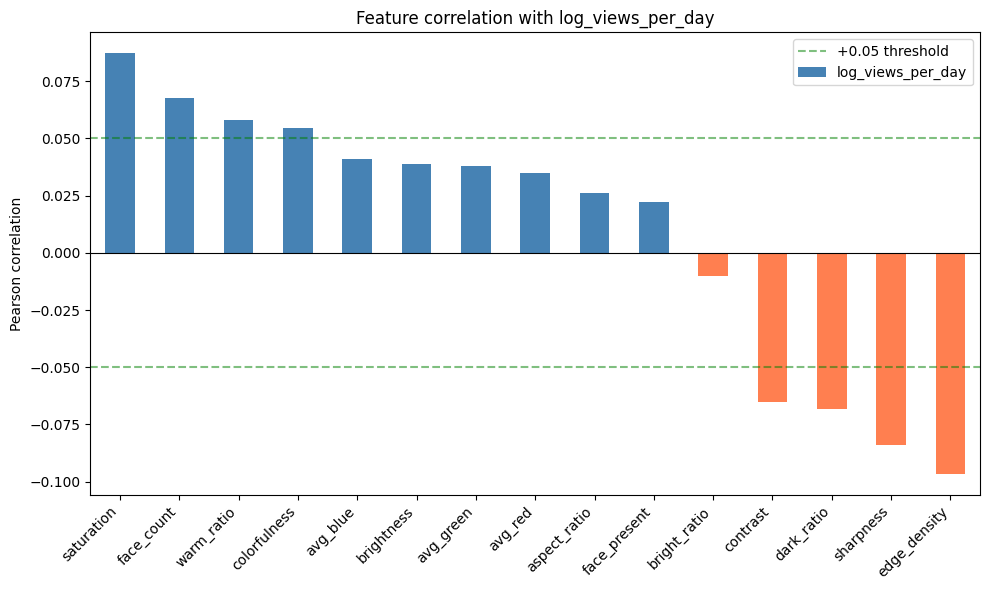


✅ Strong features (|r| >= 0.05): ['saturation', 'face_count', 'warm_ratio', 'colorfulness', 'contrast', 'dark_ratio', 'sharpness', 'edge_density']
⚠️  Weak features   (|r| <  0.05): ['avg_blue', 'brightness', 'avg_green', 'avg_red', 'aspect_ratio', 'face_present', 'bright_ratio']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#df = pd.read_csv(f"{BASE}/Project2data/processed/visual_features.csv")

# ── merge visual features with aligned df to get the target variable ──────────
df_merged = df_aligned.merge(df_visual, on="video_id", how="inner")
print(f"Merged shape: {df_merged.shape}")

# ── define your 15 features and target ───────────────────────────────────────
feature_cols = [
    "brightness", "contrast", "saturation", "colorfulness",
    "edge_density", "sharpness", "avg_red", "avg_green", "avg_blue",
    "warm_ratio", "dark_ratio", "bright_ratio", "aspect_ratio",
    "face_count", "face_present"
]

target = "log_views_per_day"

# ── correlation of each feature against the target ───────────────────────────
correlations = df_merged[feature_cols + [target]].corr()[target].drop(target)
correlations = correlations.sort_values(ascending=False)

print("\nCorrelation with log_views_per_day:")
print(correlations.round(4))

# ── plot it ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
colors = ["steelblue" if x > 0 else "coral" for x in correlations]
correlations.plot(kind="bar", color=colors)
plt.axhline(y=0.05,  color="green", linestyle="--", alpha=0.5, label="+0.05 threshold")
plt.axhline(y=-0.05, color="green", linestyle="--", alpha=0.5)
plt.axhline(y=0, color="black", linewidth=0.8)
plt.title("Feature correlation with log_views_per_day")
plt.ylabel("Pearson correlation")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

# ── flag weak features ────────────────────────────────────────────────────────
weak   = correlations[correlations.abs() < 0.05].index.tolist()
strong = correlations[correlations.abs() >= 0.05].index.tolist()

print(f"\n✅ Strong features (|r| >= 0.05): {strong}")
print(f"⚠️  Weak features   (|r| <  0.05): {weak}")